# Inception Score & FID

The introduction and implementations of Inception Score and FID.

Written by yuanjk0921@outlook.com

Updated on March 5, 2025

**Contents**
- Inception Score
- FID
- PyTorch Implementations

**References**
- [**Improved Techniques for Training GANs** *(NeurIPS 2016)*](https://arxiv.org/pdf/1606.03498): The paper which proposes Inception Score.
- [**GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium** *(NeurIPS 2017)*](https://arxiv.org/pdf/1706.08500): The paper which proposes FID.


## Inception Score

Inception Score calculates <font color=red>KL divergence between p(y|x) and p(y)</font> that aims to <font color=red>minimize entropy across samples</font> and <font color=red>maximize entropy across classes</font> for image generation evaluation.

## FID

FID calculates <font color=red>Fréchet distance</font> between Gaussian distributions of <font color=red>InceptionNet features</font> of <font color=red>real-world data</font> and <font color=red>synthetic data</font> for image generation evaluation.

<font color=red>
$$d^2((\boldsymbol{m},\boldsymbol{C}),(\boldsymbol{m}_{\omega},\boldsymbol{C}_{\omega}))=||\boldsymbol{m}-\boldsymbol{m}_{\omega}||_2^2+\mathrm{Tr}(\boldsymbol{C}+\boldsymbol{C}_{\omega}-2(\boldsymbol{C}\boldsymbol{C}_{\omega})^{1/2}) \ \ \text{[Eq. (6) of the FID paper]}.$$
</font>

## PyTorch Implementations

In [1]:
## --------------------------------------------------------------------------------
## Prepare InceptionV3 model
## --------------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

class InceptionV3(nn.Module):
    """Borrowed from https://github.com/mseitzer/pytorch-fid/blob/master/src/pytorch_fid/inception.py and simplified it"""
    """Pretrained InceptionV3 netwaork returning feature maps"""
    """Use pretrained Tensorflow checkpoint for comparable results"""

    ## Default block to output features
    DEFAULT_BLOCK_INDEX = 3

    ## Feature dimension to block index
    BLOCK_INDEX_BY_DIM = {64: 0, 192: 1, 768: 2, 2048: 3}

    def __init__(self,
                 output_blocks=(DEFAULT_BLOCK_INDEX,),
                 resize_input=True,
                 normalize_input=True,
                 inception_score=False,
                 inception_path=""):
        super(InceptionV3, self).__init__()

        self.resize_input = resize_input
        self.normalize_input = normalize_input
        self.inception_score = inception_score
        self.output_blocks = sorted(output_blocks)
        self.last_needed_block = max(output_blocks)

        assert self.last_needed_block <= 3, 'Last possible output block index is 3'
        if self.inception_score:
            assert self.last_needed_block == 3

        self.blocks = nn.ModuleList()

        inception = tf_inception_v3(inception_path)

        # Block 0: input to maxpool1
        block0 = [
            inception.Conv2d_1a_3x3,
            inception.Conv2d_2a_3x3,
            inception.Conv2d_2b_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2)
        ]
        self.blocks.append(nn.Sequential(*block0))

        # Block 1: maxpool1 to maxpool2
        if self.last_needed_block >= 1:
            block1 = [
                inception.Conv2d_3b_1x1,
                inception.Conv2d_4a_3x3,
                nn.MaxPool2d(kernel_size=3, stride=2)
            ]
            self.blocks.append(nn.Sequential(*block1))

        # Block 2: maxpool2 to aux classifier
        if self.last_needed_block >= 2:
            block2 = [
                inception.Mixed_5b,
                inception.Mixed_5c,
                inception.Mixed_5d,
                inception.Mixed_6a,
                inception.Mixed_6b,
                inception.Mixed_6c,
                inception.Mixed_6d,
                inception.Mixed_6e,
            ]
            self.blocks.append(nn.Sequential(*block2))

        # Block 3: aux classifier to final avgpool
        if self.last_needed_block >= 3:
            block3 = [
                inception.Mixed_7a,
                inception.Mixed_7b,
                inception.Mixed_7c,
                nn.AdaptiveAvgPool2d(output_size=(1, 1))
            ]
            self.blocks.append(nn.Sequential(*block3))

        if self.inception_score:
            self.fc = inception.fc  # (2048, 1008)

        for param in self.parameters():
            param.requires_grad = False

    def forward(self, inp):
        ## inp: input tensor with size [B, 3, H, W] range (0, 1)
        outp = []
        x = inp

        if self.resize_input:
            x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
        if self.normalize_input:
            x = 2 * x - 1  # (0, 1) -> (-1, 1)

        for idx, block in enumerate(self.blocks):
            x = block(x)
            if idx in self.output_blocks:
                outp.append(x)
            if idx == self.last_needed_block:
                break

        if self.inception_score:
            x = outp[-1]
            x = torch.flatten(x, 1)
            x = x.mm(self.fc.weight.T)
            return [x]

        return outp


def _inception_v3(*args, **kwargs):
    try:
        version = tuple(map(int, torchvision.__version__.split('.')[:2]))
    except ValueError:
        version = (0,)

    if version >= (0, 6):
        kwargs['init_weights'] = False

    if version < (0, 13) and 'weights' in kwargs:
        if kwargs['weights'] == 'DEFAULT':
            kwargs['pretrained'] = True
        elif kwargs['weights'] is None:
            kwargs['pretrained'] = False
        else:
            raise ValueError(
                'weights=={} not supported in torchvision {}'.format(
                    kwargs['weights'], torchvision.__version__
                )
            )
        del kwargs['weights']
    return torchvision.models.inception_v3(*args, **kwargs)

    
def tf_inception_v3(inception_path):
    inception = _inception_v3(num_classes=1008, aux_logits=False, weights=None)
    inception.Mixed_5b = TFInceptionA(192, pool_features=32)
    inception.Mixed_5c = TFInceptionA(256, pool_features=64)
    inception.Mixed_5d = TFInceptionA(288, pool_features=64)
    inception.Mixed_6b = TFInceptionC(768, channels_7x7=128)
    inception.Mixed_6c = TFInceptionC(768, channels_7x7=160)
    inception.Mixed_6d = TFInceptionC(768, channels_7x7=160)
    inception.Mixed_6e = TFInceptionC(768, channels_7x7=192)
    inception.Mixed_7b = TFInceptionE_1(1280)
    inception.Mixed_7c = TFInceptionE_2(2048)
    state_dict = torch.load(inception_path, map_location="cpu")
    inception.load_state_dict(state_dict)
    return inception


class TFInceptionA(torchvision.models.inception.InceptionA):
    def __init__(self, in_channels, pool_features):
        super(TFInceptionA, self).__init__(in_channels, pool_features)

    def forward(self, x):
        branch1x1 = self.branch1x1(x)
        branch5x5 = self.branch5x5_1(x)
        branch5x5 = self.branch5x5_2(branch5x5)
        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = self.branch3x3dbl_3(branch3x3dbl)
        branch_pool = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1, count_include_pad=False)
        branch_pool = self.branch_pool(branch_pool)
        outputs = [branch1x1, branch5x5, branch3x3dbl, branch_pool]
        return torch.cat(outputs, 1)


class TFInceptionC(torchvision.models.inception.InceptionC):
    def __init__(self, in_channels, channels_7x7):
        super(TFInceptionC, self).__init__(in_channels, channels_7x7)

    def forward(self, x):
        branch1x1 = self.branch1x1(x)
        branch7x7 = self.branch7x7_1(x)
        branch7x7 = self.branch7x7_2(branch7x7)
        branch7x7 = self.branch7x7_3(branch7x7)
        branch7x7dbl = self.branch7x7dbl_1(x)
        branch7x7dbl = self.branch7x7dbl_2(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_3(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_4(branch7x7dbl)
        branch7x7dbl = self.branch7x7dbl_5(branch7x7dbl)
        branch_pool = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1, count_include_pad=False)
        branch_pool = self.branch_pool(branch_pool)
        outputs = [branch1x1, branch7x7, branch7x7dbl, branch_pool]
        return torch.cat(outputs, 1)


class TFInceptionE_1(torchvision.models.inception.InceptionE):
    def __init__(self, in_channels):
        super(TFInceptionE_1, self).__init__(in_channels)

    def forward(self, x):
        branch1x1 = self.branch1x1(x)
        branch3x3 = self.branch3x3_1(x)
        branch3x3 = [self.branch3x3_2a(branch3x3), self.branch3x3_2b(branch3x3),]
        branch3x3 = torch.cat(branch3x3, 1)
        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = [self.branch3x3dbl_3a(branch3x3dbl), self.branch3x3dbl_3b(branch3x3dbl),]
        branch3x3dbl = torch.cat(branch3x3dbl, 1)
        branch_pool = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1, count_include_pad=False)
        branch_pool = self.branch_pool(branch_pool)
        outputs = [branch1x1, branch3x3, branch3x3dbl, branch_pool]
        return torch.cat(outputs, 1)


class TFInceptionE_2(torchvision.models.inception.InceptionE):
    def __init__(self, in_channels):
        super(TFInceptionE_2, self).__init__(in_channels)

    def forward(self, x):
        branch1x1 = self.branch1x1(x)
        branch3x3 = self.branch3x3_1(x)
        branch3x3 = [self.branch3x3_2a(branch3x3), self.branch3x3_2b(branch3x3)]
        branch3x3 = torch.cat(branch3x3, 1)
        branch3x3dbl = self.branch3x3dbl_1(x)
        branch3x3dbl = self.branch3x3dbl_2(branch3x3dbl)
        branch3x3dbl = [self.branch3x3dbl_3a(branch3x3dbl), self.branch3x3dbl_3b(branch3x3dbl)]
        branch3x3dbl = torch.cat(branch3x3dbl, 1)
        branch_pool = F.max_pool2d(x, kernel_size=3, stride=1, padding=1)
        branch_pool = self.branch_pool(branch_pool)
        outputs = [branch1x1, branch3x3, branch3x3dbl, branch_pool]
        return torch.cat(outputs, 1)

/usr/local/python/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: ''If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/usr/local/python/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## --------------------------------------------------------------------------------
## Prepare evaluation model
## --------------------------------------------------------------------------------
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_path = f"/apdcephfs_nj8/share_301739632/jarvizhang/workspace/eval_assets/FID/pt_inception-2015-12-05-6726825d.pth"  # remove
coco_stats_path = f"/apdcephfs_nj8/share_301739632/jarvizhang/workspace/eval_assets/FID/coco_val_fid_stats.pt"  # remove
coco_stats = torch.load(coco_stats_path)
mu_coco = coco_stats['mu']  # [2048,]
sigma_coco = coco_stats['sigma']  # [2048, 2048]

dims = 2048  # feature dimensions for calculating FID score

fid_model = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[dims]], inception_score=False, inception_path=model_path).to(device)
ics_model = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[dims]], inception_score=True, inception_path=model_path).to(device)
print(f"=> Finish loading model")

=> Finish loading model


In [3]:
## --------------------------------------------------------------------------------
## Prepare data
## --------------------------------------------------------------------------------
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, image_paths, image_size):
        self.image_paths = image_paths
        self.transform = transforms.Compose([
            transforms.Resize(
                image_size, interpolation=transforms.InterpolationMode.BICUBIC,
                antialias=True,
            ),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        file_path = self.image_paths[index]
        image = self.transform(Image.open(file_path))
        return image, file_path
# remove
image_paths = list()
batch_size = 64
sample_num = batch_size * 100
for root, _, files in os.walk("/apdcephfs_cq8/share_2938211/junkunyuan/project/hunyuan_multimodal/inference-time-scaling/text2image-test-time-scaling/all_results/flux-T2ICompBench/sample"):
    for file in files:
        path = os.path.join(root, file)
        image_paths.append(path)
    if len(image_paths) > sample_num:
        image_paths = image_paths[:sample_num]
        break
print(f"Inference data {len(image_paths)}")

dataset = ImageDataset(image_paths=image_paths, image_size=256)
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, num_workers=8, shuffle=False)

Inference data 6400


In [4]:
## --------------------------------------------------------------------------------
## Calculate Fréchet distance for FID estimation
## --------------------------------------------------------------------------------
from scipy import linalg

def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Borrowed from https://github.com/mseitzer/pytorch-fid/blob/master/src/pytorch_fid/fid_score.py and simplified it"""
    """Numpy implementation of the Frechet Distance."""

    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    assert mu1.shape == mu2.shape, 'Training and test mean vectors have different lengths'
    assert sigma1.shape == sigma2.shape, 'Training and test covariances have different dimensions'

    diff = mu1 - mu2

    # Product might be almost singular
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        msg = ('fid calculation produces singular product; '
               'adding %s to diagonal of cov estimates') % eps
        print(msg)
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # Numerical error might give slight imaginary component
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            raise ValueError('Imaginary component {}'.format(m))
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    return (diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean)

In [5]:
## --------------------------------------------------------------------------------
## Calculate Inception Score
## --------------------------------------------------------------------------------
def calculate_inception_score(feature, splits=10, shuffle=True, rng_seed=2024):
    assert torch.is_tensor(feature) and feature.dim() == 2
    B = feature.shape[0]
    if shuffle:
        rng = np.random.RandomState(rng_seed)
        feature = feature[rng.permutation(B), :]
    feature = feature.double()

    p = feature.softmax(dim=1)
    log_p = feature.log_softmax(dim=1)

    scores = []
    for i in range(splits):
        p_chunk = p[(i * B // splits) : ((i + 1) * B // splits), :]
        log_p_chunk = log_p[(i * B // splits) : ((i + 1) * B // splits), :]
        q_chunk = p_chunk.mean(dim=0, keepdim=True)
        kl = p_chunk * (log_p_chunk - q_chunk.log())
        kl = kl.sum(dim=1).mean().exp().item()
        scores.append(kl)

    return float(np.mean(scores)), float(np.std(scores))

[batch] 1/100    [data] 32    [FID] 248.6    [FID all] 248.6    [FID data all] 211.1    [Inception Score] 2.3    [Inception Score all] 2.3
[batch] 10/100    [data] 320    [FID] 249.6    [FID all] 127.0    [FID data all] 93.0    [Inception Score] 2.0    [Inception Score all] 6.1
[batch] 20/100    [data] 640    [FID] 243.7    [FID all] 93.4    [FID data all] 60.0    [Inception Score] 2.2    [Inception Score all] 7.9
[batch] 30/100    [data] 960    [FID] 243.6    [FID all] 78.2    [FID data all] 44.1    [Inception Score] 2.1    [Inception Score all] 9.0
[batch] 40/100    [data] 1280    [FID] 243.0    [FID all] 69.4    [FID data all] 35.1    [Inception Score] 2.2    [Inception Score all] 9.7
[batch] 50/100    [data] 1600    [FID] 246.3    [FID all] 64.0    [FID data all] 28.6    [Inception Score] 2.1    [Inception Score all] 9.6
[batch] 60/100    [data] 1920    [FID] 246.2    [FID all] 60.8    [FID data all] 24.0    [Inception Score] 2.1    [Inception Score all] 9.8
[batch] 70/100    [data

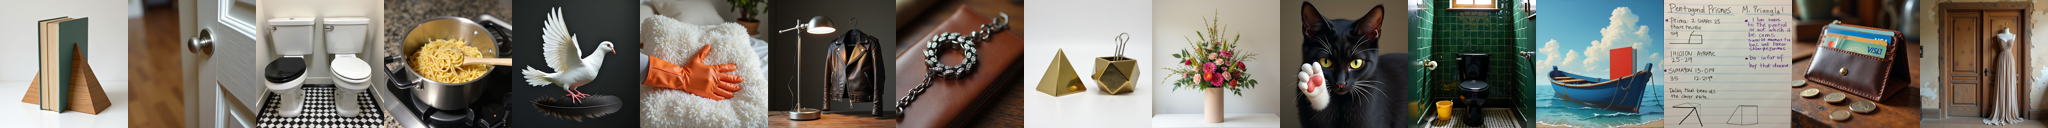

In [6]:
## --------------------------------------------------------------------------------
## Evaluate all data
## --------------------------------------------------------------------------------
import torch.nn.functional as F
from diffusers.utils import make_image_grid

fid_feats_all = list()
fid_feats_data_all = list()
ics_feats_all = list()
half_batch = batch_size // 2
for idx, (images, file_paths) in enumerate(dataloader, start=1):
    images_input = images[:half_batch].to(device=device)
    images_data = images[half_batch:].to(device=device)

    ## Get inception features
    fid_feats = fid_model(images_input)[0].flatten(1).cpu().numpy()  # [B, dims, 1, 1]
    fid_feats_data = fid_model(images_data)[0].flatten(1).cpu().numpy()  # [B, dims, 1, 1]
    ics_feats = ics_model(images_input)[0].flatten(1).cpu().numpy()  # [B, 1008, 1, 1]

    ## Calculate FID score of current batch data
    mu_feature, sigma_feature = np.mean(fid_feats, axis=0), np.cov(fid_feats, rowvar=False)
    fid_score = calculate_frechet_distance(mu_feature, sigma_feature, mu_coco, sigma_coco)

    ## Calculate Inception score of current batch data
    ics_mean, ics_std = calculate_inception_score(torch.from_numpy(ics_feats))
    
    ## Calculate FID score of all processed data
    fid_feats_all.append(fid_feats)
    fid_feats = np.concatenate(fid_feats_all, axis=0)
    fid_feats_data_all.append(fid_feats_data)
    fid_feats_data = np.concatenate(fid_feats_data_all, axis=0)
    mu_feature, sigma_feature = np.mean(fid_feats, axis=0), np.cov(fid_feats, rowvar=False)
    mu_feature_data, sigma_feature_data = np.mean(fid_feats_data, axis=0), np.cov(fid_feats_data, rowvar=False)
    fid_score_all = calculate_frechet_distance(mu_feature, sigma_feature, mu_coco, sigma_coco)
    fid_score_data_all = calculate_frechet_distance(mu_feature, sigma_feature, mu_feature_data, sigma_feature_data)

    ## Calculate Inception score of all processed data
    ics_feats_all.append(ics_feats)
    ics_feats = np.concatenate(ics_feats_all, axis=0)
    ics_mean_all, ics_std_all = calculate_inception_score(torch.from_numpy(ics_feats))
    
    if idx == 1 or idx % 10 == 0 or idx == len(dataloader):
        print(f"[batch] {idx}/{len(dataloader)}    [data] {len(fid_feats)}    [FID] {fid_score:.1f}    [FID all] {fid_score_all:.1f}    [FID data all] {fid_score_data_all:.1f}    [Inception Score] {ics_mean:.1f}    [Inception Score all] {ics_mean_all:.1f}")
    
## Show results
images = [Image.open(path).resize((128, 128)) for path in file_paths[:16]]
image_grid = make_image_grid(images, rows=1, cols=len(images))
display(image_grid)

**Observations:**

- Both Inception Score and FID are <font color=red>sensitive to evaluation data quantity</font>.
- FID is <font color=red>sensitive</font> to the <font color=red>distribution gap</font> between <font color=red>evaluation data</font> and <font color=red>target data</font>.